## 가장 단순한 버전이다. 
1. DEM은 사용하지 않는다.  
2. 그냥 48채널의 이미지 처럼 다룬다. (2D conv 사용)  
3. 별 다른 transform(데이터 전처리)을 하지 않았다. 
4. NDVI없이 B,G,R, NIR만 이용했다.

In [88]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
import torch
import tifffile as tiff
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from sklearn.model_selection import train_test_split
import torch.nn as nn
from tqdm import tqdm
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import torch.optim as optim

In [89]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

### dataset 클래스 정의

In [91]:
import os
import pandas as pd
import tifffile as tiff
from torch.utils.data import Dataset
import math


class TiffDataset(Dataset):
    def __init__(self, large_tif_dir, file_list, label_file, patch_size=3, box_filter_fn=None, transform=None):
        """
        Args:
            large_tif_dir (str): 여러 개의 큰 TIFF 파일이 저장된 디렉토리 경로.
            file_list (list of str): 처리할 원천 데이터 파일명 리스트.
            label_file (str): 라벨 정보를 담은 CSV 파일 경로 ("file", "x_pos", "y_pos", "label" 열 포함).
            patch_size (int): 슬라이싱할 이미지의 크기 (기본값: 3).
            box_filter_fn (callable, optional): 박스 번호 필터링 함수. 
                - 입력: 박스 번호 (1부터 100까지)
                - 출력: 해당 박스를 사용할지 여부 (True/False).
                - 기본값: None (모든 박스 사용).
            transform (callable, optional): 이미지 전처리에 사용할 함수.
        """
        self.large_tif_dir = large_tif_dir
        self.file_list = set(file_list)
        self.label_df = pd.read_csv(label_file)

        # 박스 필터 함수 설정 (기본값: 모든 박스 사용)
        self.box_filter_fn = box_filter_fn or (lambda box_number: True)

        # 파일명 필터링: file_list에 있는 파일만 유지
        self.label_df = self.label_df[self.label_df['file'].isin(self.file_list)].reset_index(drop=True)

        # 박스 번호 필터링
        self.label_df = self.label_df[self.label_df['box_number'].apply(self.box_filter_fn)].reset_index(drop=True)

        self.patch_size = patch_size
        self.transform = transform

        # 각 파일명을 키로 하고 이미지를 값으로 가지는 딕셔너리
        self.image_cache = {}

    def _load_image(self, file_name):
        """파일 이름에 해당하는 이미지를 로드하여 캐시에 저장."""
        if file_name not in self.image_cache:
            file_path = os.path.join(self.large_tif_dir, file_name)
            if not os.path.exists(file_path):
                raise FileNotFoundError(f"Image file '{file_path}' not found.")
            self.image_cache[file_name] = tiff.imread(file_path)
        return self.image_cache[file_name]

    def __len__(self):
        return len(self.label_df)

    def __getitem__(self, idx):
        # 현재 인덱스에 해당하는 데이터 가져오기
        row = self.label_df.iloc[idx]
        file_name = row["file"]
        x, y = row["x_pos"], row["y_pos"]
        label = row["label"]

        # 이미지 로드
        image = self._load_image(file_name)
        image_height, image_width = image.shape[:2]

        # 범위 검사
        if x < 0 or y < 0 or x + self.patch_size > image_width or y + self.patch_size > image_height:
            raise ValueError(f"Patch at position (x={x}, y={y}) exceeds bounds of image '{file_name}'.")

        # 이미지 슬라이싱
        patch = image[y:y + self.patch_size, x:x + self.patch_size]

        # 전처리 적용
        if self.transform:
            patch = self.transform(patch)

        return patch, label


### 테스트 지역 선별  
train data와 validaiton data가 인접한 패치가 되면 일반화 성능을 올바르게 검증 할 수 없을 것이다.  
따라서 train data에서 사용한 지역과 어느정도는 떯어진 지역의 패치를 validation data로 이용하도록 한다.  
3000*3000의 정사각형 지역(이미지)를 300*300 크기의 지역 100개로 나눈 후 이중 임의로 약 20개를 뽑아서 validation data로 이용했다.  
아래는 validation data의 위치를 시각화 하는 코드이다.(빨간색이 테스트 지역임)

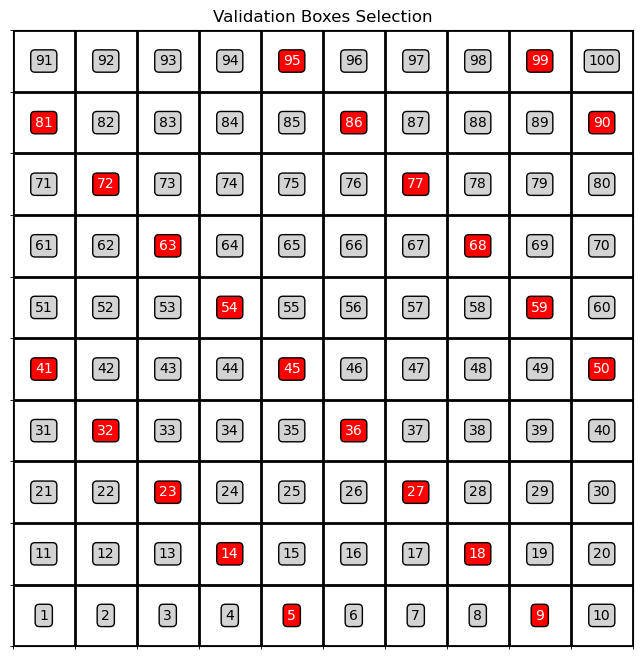

In [99]:
import matplotlib.pyplot as plt
import numpy as np

# 10x10 격자에서 1부터 100까지 박스 번호 생성
grid_size = 10
box_numbers = np.arange(1, 101).reshape(grid_size, grid_size)

#test_filter = lambda box_number: box_number in {14, 8, 27, 49, 84, 100, 78, 11, 90, 58, 19, 64, 36, 82, 96, 92, 33, 31, 69, 42} #임의의 테스트 지역
test_filter = lambda box_number: (box_number % 9 == 0 or box_number % 9 == 5)
# 테스트할 박스 선택
test_boxes = np.vectorize(test_filter)(box_numbers)

# 시각화
fig, ax = plt.subplots(figsize=(8, 8))
ax.set_xticks(np.arange(grid_size + 1) - 0.5, minor=True)
ax.set_yticks(np.arange(grid_size + 1) - 0.5, minor=True)
ax.grid(which='minor', color='black', linestyle='-', linewidth=2)

# 박스에 숫자 표시 및 색상 적용
for i in range(grid_size):
    for j in range(grid_size):
        box_number = box_numbers[i, j]
        ax.text(j, i, str(box_number), ha='center', va='center', fontsize=10, 
                color='white' if test_boxes[i, j] else 'black', 
                bbox=dict(facecolor='red' if test_boxes[i, j] else 'lightgray', 
                          edgecolor='black', boxstyle='round,pad=0.3'))

# 축을 숨김
ax.set_xticks([])
ax.set_yticks([])

plt.title("Validation Boxes Selection")
plt.show()


In [96]:
# 이미지 전처리 (Naive)
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Lambda(lambda x: x.float()),  # uint16 → float 변환
])

train_dataset = TiffDataset(
    large_tif_dir = r"C:\Users\taebin\Desktop\my_study\capstone_design\data3\원천 데이터\naive",
    file_list = ["jiri_1.tif", "jiri_2.tif", "sobaek.tif"], #전체 지역을 모두 사용한다.
    label_file = r"C:\Users\taebin\Desktop\my_study\capstone_design\data3\라벨링 데이터\label_mapping_sampled.csv",
    box_filter_fn = lambda box_number: not test_filter(box_number),
    transform=transform
)

val_dataset = TiffDataset(
    large_tif_dir = r"C:\Users\taebin\Desktop\my_study\capstone_design\data3\원천 데이터\naive",
    file_list = ["jiri_1.tif", "jiri_2.tif", "sobaek.tif"], #전체 지역을 모두 사용한다.
    label_file = r"C:\Users\taebin\Desktop\my_study\capstone_design\data3\라벨링 데이터\label_mapping_sampled.csv",
    box_filter_fn = test_filter,
    transform=transform
)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=True)

### resnet과 같은 구조의 모델

In [97]:
class BasicBlock(nn.Module):
    def __init__(self, in_channels, out_channels, stride=1):
        super(BasicBlock, self).__init__()
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3, stride=stride, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.relu = nn.ReLU(inplace=True)
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_channels)
        
        self.downsample = None
        if stride != 1 or in_channels != out_channels:
            self.downsample = nn.Sequential(
                nn.Conv2d(in_channels, out_channels, kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(out_channels)
            )
        
    def forward(self, x):
        identity = x
        if self.downsample is not None:
            identity = self.downsample(x)
        
        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu(out)
        out = self.conv2(out)
        out = self.bn2(out)
        out += identity
        out = self.relu(out)
        return out

class ResNetLike(nn.Module):
    def __init__(self, num_classes=8):
        super(ResNetLike, self).__init__()
        self.in_channels = 64
        
        # 48 채널 입력을 처리할 Conv Layer
        self.conv1 = nn.Conv2d(48, 64, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(64)
        self.relu = nn.ReLU(inplace=True)
        
        self.layer1 = self._make_layer(64, 2, stride=1)
        self.layer2 = self._make_layer(128, 2, stride=1)
        self.layer3 = self._make_layer(256, 2, stride=1)
        
        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        self.fc = nn.Linear(256, num_classes)
    
    def _make_layer(self, out_channels, blocks, stride):
        layers = []
        layers.append(BasicBlock(self.in_channels, out_channels, stride))
        self.in_channels = out_channels
        for _ in range(1, blocks):
            layers.append(BasicBlock(out_channels, out_channels))
        return nn.Sequential(*layers)
    
    def forward(self, x):
        x = self.conv1(x)
        x = self.bn1(x)
        x = self.relu(x)
        
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        
        x = self.avgpool(x)
        x = torch.flatten(x, 1)
        x = self.fc(x)
        return x

### train 함수, evaluate 함수

In [100]:
def train_model(model, train_loader, val_loader, criterion, optimizer, num_epochs=50, patience=10):
    train_losses = []
    val_losses = []
    best_val_loss = float('inf')
    best_model_state = None
    no_improve_count = 0

    for epoch in range(num_epochs):
        model.train()
        running_loss = 0.0
        correct = 0
        total = 0

        # Training loop
        for images, labels in tqdm(train_loader):
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()

            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

        train_loss = running_loss / len(train_loader)
        train_accuracy = 100 * correct / total
        train_losses.append(train_loss)

        # Validation loop
        model.eval()
        val_running_loss = 0.0
        val_correct = 0
        val_total = 0
        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)

                outputs = model(images)
                loss = criterion(outputs, labels)

                val_running_loss += loss.item()
                _, predicted = torch.max(outputs, 1)
                val_total += labels.size(0)
                val_correct += (predicted == labels).sum().item()

        val_loss = val_running_loss / len(val_loader)
        val_accuracy = 100 * val_correct / val_total
        val_losses.append(val_loss)

        print(f"Epoch [{epoch+1}/{num_epochs}], "
              f"Train Loss: {train_loss:.4f}, Train Accuracy: {train_accuracy:.2f}%, "
              f"Val Loss: {val_loss:.4f}, Val Accuracy: {val_accuracy:.2f}%")

        # Check for improvement
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_model_state = model.state_dict()
            no_improve_count = 0
        else:
            no_improve_count += 1

        # Early stopping
        if no_improve_count >= patience:
            print("Early stopping triggered. Training stopped.")
            break

    # Load the best model state
    if best_model_state:
        model.load_state_dict(best_model_state)

    return train_losses, val_losses


In [104]:
def evaluate_model_with_cm(model, val_loader, num_classes=8):
    model.eval()
    all_labels = []
    all_predictions = []
    
    with torch.no_grad():
        # tqdm으로 진행 상황 표시
        for images, labels in tqdm(val_loader, desc="Evaluation Progress"):
            images, labels = images.to(device), labels.to(device)  # device로 데이터 이동

            outputs = model(images)
            _, predicted = torch.max(outputs, 1)
            
            all_labels.extend(labels.cpu().numpy())  # 실제 라벨
            all_predictions.extend(predicted.cpu().numpy())  # 예측된 라벨

    # 라벨 범위 설정
    labels = np.arange(0, num_classes)

    # Confusion matrix 계산
    cm = confusion_matrix(all_labels, all_predictions, labels=labels)

    # Confusion matrix 시각화
    plt.figure(figsize=(10, 7))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=labels, yticklabels=labels)
    plt.xlabel('Predicted Labels')
    plt.ylabel('True Labels')
    plt.title('Confusion Matrix')
    plt.show()

    # Classification report 계산
    report = classification_report(all_labels, all_predictions, labels=labels, target_names=[str(label) for label in labels])
    
    print("Classification Report:")
    print(report)

### 모델 훈련

In [107]:
model = ResNetLike(num_classes=8).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [108]:
train_losses, val_losses = train_model(model, train_loader, val_loader, criterion, optimizer, num_epochs=100)
torch.save(model, "naive_100.pth")

100%|██████████| 3733/3733 [06:13<00:00, 10.00it/s]


Epoch [1/100], Train Loss: 0.5968, Train Accuracy: 78.16%, Val Loss: 0.5573, Val Accuracy: 79.37%


100%|██████████| 3733/3733 [06:12<00:00, 10.02it/s]


Epoch [2/100], Train Loss: 0.4686, Train Accuracy: 82.95%, Val Loss: 0.6350, Val Accuracy: 77.44%


100%|██████████| 3733/3733 [06:40<00:00,  9.32it/s]


...

Epoch [18/100], Train Loss: 0.2114, Train Accuracy: 92.31%, Val Loss: 0.6345, Val Accuracy: 81.93%


100%|██████████| 3733/3733 [06:07<00:00, 10.17it/s]


Epoch [19/100], Train Loss: 0.2042, Train Accuracy: 92.48%, Val Loss: 0.5634, Val Accuracy: 85.02%


100%|██████████| 3733/3733 [06:07<00:00, 10.17it/s]


Epoch [20/100], Train Loss: 0.1991, Train Accuracy: 92.77%, Val Loss: 0.5806, Val Accuracy: 84.69%
Early stopping triggered. Training stopped.


### 모델 테스트

train_data

Evaluation Progress: 100%|██████████| 3733/3733 [01:22<00:00, 45.04it/s]


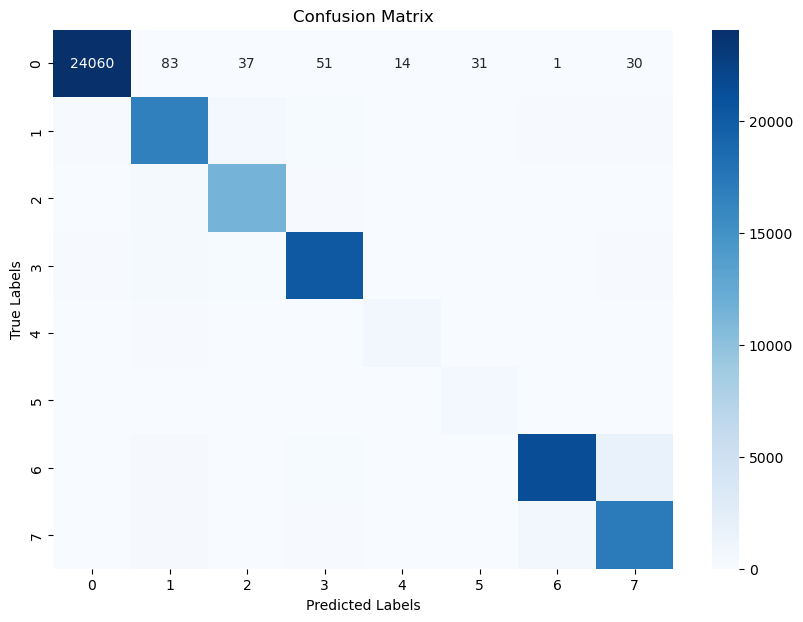

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.99      0.99     24307
           1       0.90      0.93      0.92     17930
           2       0.92      0.95      0.94     12060
           3       0.96      0.95      0.95     21424
           4       0.82      0.75      0.79       941
           5       0.84      0.89      0.87       656
           6       0.96      0.90      0.93     23688
           7       0.89      0.93      0.91     18425

    accuracy                           0.94    119431
   macro avg       0.91      0.91      0.91    119431
weighted avg       0.94      0.94      0.94    119431



In [109]:
evaluate_model_with_cm(model, train_loader, num_classes=8)

validation_data

Evaluation Progress: 100%|██████████| 1169/1169 [00:25<00:00, 45.39it/s]


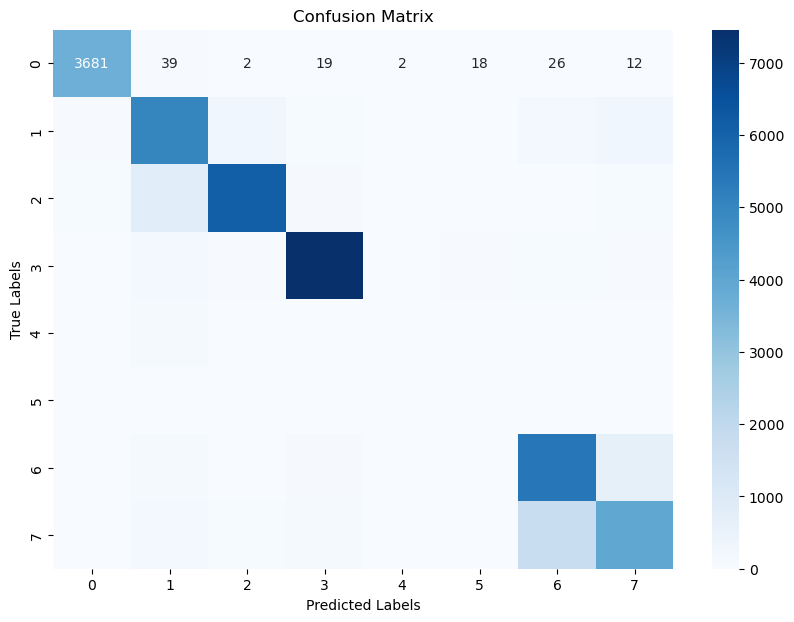

Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.97      0.96      3799
           1       0.77      0.85      0.81      5914
           2       0.93      0.85      0.89      7178
           3       0.95      0.95      0.95      7845
           4       0.45      0.12      0.19       195
           5       0.00      0.00      0.00         0
           6       0.73      0.86      0.79      6312
           7       0.79      0.65      0.71      6148

    accuracy                           0.85     37391
   macro avg       0.70      0.66      0.66     37391
weighted avg       0.85      0.85      0.85     37391



c:\Users\taebin\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\taebin\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\taebin\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [110]:
evaluate_model_with_cm(model, val_loader, num_classes=8)

## ndvi도 추가된 데이터 사용

In [111]:
train_dataset = TiffDataset(
    large_tif_dir = r"C:\Users\taebin\Desktop\my_study\capstone_design\data3\원천 데이터\with_ndvi",
    file_list = ["jiri_1.tif", "jiri_2.tif", "sobaek.tif"], #전체 지역을 모두 사용한다.
    label_file = r"C:\Users\taebin\Desktop\my_study\capstone_design\data3\라벨링 데이터\label_mapping_sampled.csv",
    box_filter_fn = lambda box_number: not test_filter(box_number),
    transform=transform
)

val_dataset = TiffDataset(
    large_tif_dir = r"C:\Users\taebin\Desktop\my_study\capstone_design\data3\원천 데이터\with_ndvi",
    file_list = ["jiri_1.tif", "jiri_2.tif", "sobaek.tif"], #전체 지역을 모두 사용한다.
    label_file = r"C:\Users\taebin\Desktop\my_study\capstone_design\data3\라벨링 데이터\label_mapping_sampled.csv",
    box_filter_fn = test_filter,
    transform=transform
)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=True)

### 60차원을 받도록 모델을 수정해야 한다.

In [112]:
class BasicBlock(nn.Module):
    def __init__(self, in_channels, out_channels, stride=1):
        super(BasicBlock, self).__init__()
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3, stride=stride, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.relu = nn.ReLU(inplace=True)
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_channels)
        
        self.downsample = None
        if stride != 1 or in_channels != out_channels:
            self.downsample = nn.Sequential(
                nn.Conv2d(in_channels, out_channels, kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(out_channels)
            )
        
    def forward(self, x):
        identity = x
        if self.downsample is not None:
            identity = self.downsample(x)
        
        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu(out)
        out = self.conv2(out)
        out = self.bn2(out)
        out += identity
        out = self.relu(out)
        return out

class ResNetLike(nn.Module):
    def __init__(self, num_classes=8):
        super(ResNetLike, self).__init__()
        self.in_channels = 64
        
        # 60 채널 입력을 처리할 Conv Layer
        self.conv1 = nn.Conv2d(60, 64, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(64)
        self.relu = nn.ReLU(inplace=True)
        
        self.layer1 = self._make_layer(64, 2, stride=1)
        self.layer2 = self._make_layer(128, 2, stride=1)
        self.layer3 = self._make_layer(256, 2, stride=1)
        
        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        self.fc = nn.Linear(256, num_classes)
    
    def _make_layer(self, out_channels, blocks, stride):
        layers = []
        layers.append(BasicBlock(self.in_channels, out_channels, stride))
        self.in_channels = out_channels
        for _ in range(1, blocks):
            layers.append(BasicBlock(out_channels, out_channels))
        return nn.Sequential(*layers)
    
    def forward(self, x):
        x = self.conv1(x)
        x = self.bn1(x)
        x = self.relu(x)
        
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        
        x = self.avgpool(x)
        x = torch.flatten(x, 1)
        x = self.fc(x)
        return x

### 모델 학습

In [113]:
model = ResNetLike(num_classes=8).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [114]:
train_losses, val_losses = train_model(model, train_loader, val_loader, criterion, optimizer, num_epochs=100)
torch.save(model, "naive_with_ndvi_100.pth")

100%|██████████| 3733/3733 [04:46<00:00, 13.04it/s]


Epoch [1/100], Train Loss: 0.6554, Train Accuracy: 75.50%, Val Loss: 0.8894, Val Accuracy: 66.83%


100%|██████████| 3733/3733 [05:10<00:00, 12.01it/s]


Epoch [2/100], Train Loss: 0.5294, Train Accuracy: 80.82%, Val Loss: 0.9998, Val Accuracy: 66.46%


100%|██████████| 3733/3733 [06:12<00:00, 10.03it/s]


...

Epoch [32/100], Train Loss: 0.1615, Train Accuracy: 94.03%, Val Loss: 0.8313, Val Accuracy: 80.80%


100%|██████████| 3733/3733 [06:10<00:00, 10.08it/s]


Epoch [33/100], Train Loss: 0.1567, Train Accuracy: 94.16%, Val Loss: 1.1170, Val Accuracy: 73.87%


100%|██████████| 3733/3733 [06:10<00:00, 10.07it/s]


Epoch [34/100], Train Loss: 0.1519, Train Accuracy: 94.31%, Val Loss: 0.7090, Val Accuracy: 83.04%
Early stopping triggered. Training stopped.


### 모델 테스트

train data

Evaluation Progress: 100%|██████████| 3733/3733 [01:22<00:00, 45.22it/s]


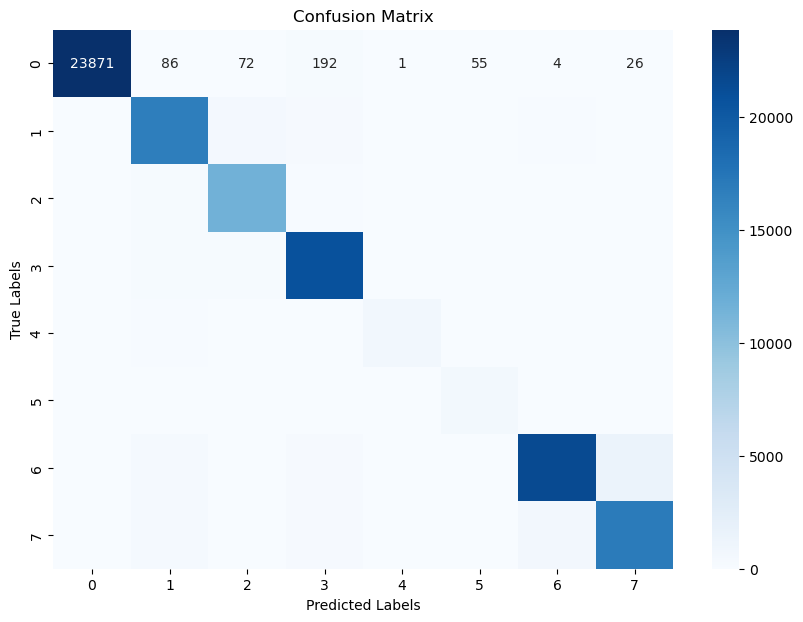

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.98      0.99     24307
           1       0.92      0.93      0.93     17930
           2       0.92      0.97      0.94     12060
           3       0.94      0.97      0.95     21424
           4       0.85      0.86      0.85       941
           5       0.89      0.86      0.87       656
           6       0.96      0.91      0.93     23688
           7       0.92      0.92      0.92     18425

    accuracy                           0.95    119431
   macro avg       0.92      0.92      0.92    119431
weighted avg       0.95      0.95      0.95    119431



In [115]:
evaluate_model_with_cm(model, train_loader, num_classes=8)

validation data

Evaluation Progress: 100%|██████████| 1169/1169 [00:26<00:00, 44.59it/s]


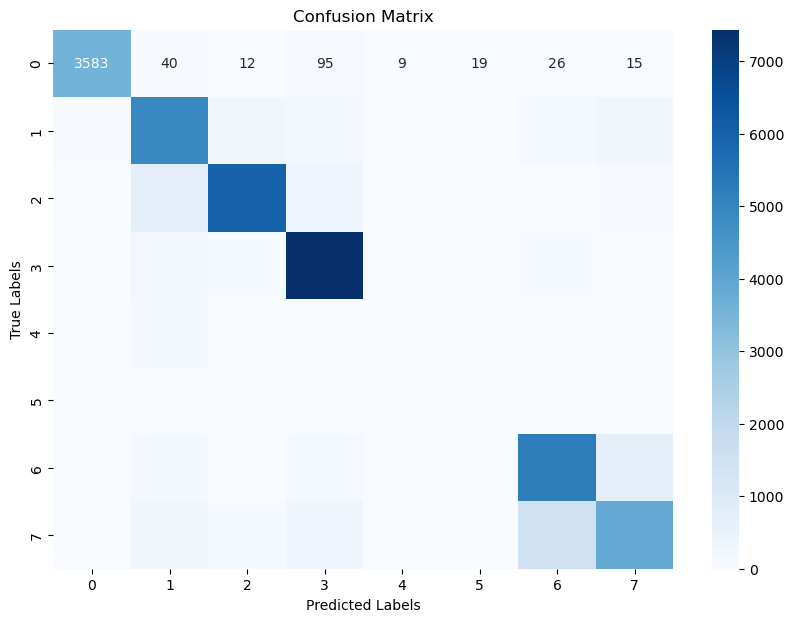

Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.94      0.96      3799
           1       0.75      0.83      0.79      5914
           2       0.92      0.83      0.88      7178
           3       0.87      0.95      0.91      7845
           4       0.15      0.04      0.06       195
           5       0.00      0.00      0.00         0
           6       0.75      0.83      0.79      6312
           7       0.77      0.63      0.69      6148

    accuracy                           0.83     37391
   macro avg       0.65      0.63      0.63     37391
weighted avg       0.83      0.83      0.83     37391



c:\Users\taebin\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\taebin\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\taebin\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [116]:
evaluate_model_with_cm(model, val_loader, num_classes=8)